In [1]:
# ============================================================================
# MULTI-MODEL SHAP ANALYSIS - LAYERED VIOLIN PLOT
# ============================================================================

import warnings
warnings.filterwarnings('ignore')
import os
os.environ["PYTHONWARNINGS"] = "ignore"

import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.pipeline import Pipeline

# ============================================================================
# DATA & MODEL LOADING (Modified for Loop)
# ============================================================================

def load_data_and_extract_estimator(train_path, test_path, model_path, target_col):
    """Loads data once and extracts the specific estimator from pipeline."""
    
    # 1. Load Data
    df_train = pd.read_parquet(train_path) if train_path.endswith('.parquet') else pd.read_excel(train_path)
    df_test = pd.read_parquet(test_path) if test_path.endswith('.parquet') else pd.read_excel(test_path)
    
    # 2. Combine & Clean
    df_all = pd.concat([df_train, df_test], axis=0, ignore_index=True)
    
    # Remove Target and unwanted columns
    cols_to_drop = [target_col] + [c for c in df_all.columns if 'Unnamed' in c]
    X_raw = df_all.drop(columns=cols_to_drop, errors='ignore')
    # Ensure numeric
    X_numeric = X_raw.select_dtypes(include=[np.number])
    
    # 3. Load Model
    print(f"  -> Loading model from: {model_path}")
    try:
        pipeline = joblib.load(model_path)
    except FileNotFoundError:
        print(f"  [!] File not found: {model_path}")
        return None, None

    # 4. Handle Pipeline
    if isinstance(pipeline, Pipeline):
        X_final = X_numeric.copy()
        # Transform data using steps BEFORE the final model
        if hasattr(pipeline, 'steps'):
            for name, step in pipeline.steps[:-1]:
                X_final = step.transform(X_final)
            
            estimator = pipeline.steps[-1][1]
            # Convert back to DF for feature names
            X_final = pd.DataFrame(X_final, columns=X_numeric.columns)
    else:
        estimator = pipeline
        X_final = X_numeric
        
    return X_final, estimator

# ============================================================================
# SMART EXPLAINER SELECTION
# ============================================================================

def get_shap_values(model, X):
    model_name = str(type(model)).lower()
    print(f"  -> Detected model type: {type(model).__name__}")

    tree_models = ['randomforest', 'xgboost', 'gradientboosting', 'decisiontree', 'tree', 'lgbm', 'catboost']
    
    if any(tm in model_name for tm in tree_models):
        print("  -> Using TreeExplainer")
        explainer = shap.TreeExplainer(model)
        # Używamy explainer(X) zamiast shap_values(X) dla nowszych wersji SHAP, 
        # co zwraca obiekt Explanation, który jest łatwiejszy w obsłudze.
        shap_values = explainer.shap_values(X)
    else:
        print("  -> Using KernelExplainer")
        background = shap.kmeans(X, 50) if len(X) > 100 else X
        explainer = shap.KernelExplainer(model.predict, background)
        shap_values = explainer.shap_values(X)

    if isinstance(shap_values, list):
        print(f"  -> List detected (length {len(shap_values)}). Selecting index 1.")
        # Wybieramy klasę 1 (zazwyczaj pozytywną), o ile istnieją co najmniej dwie
        shap_values = shap_values[1] if len(shap_values) > 1 else shap_values[0]

    # Jeśli shap_values to tablica 3D (np. (n_samples, n_features, n_classes))
    if isinstance(shap_values, np.ndarray) and len(shap_values.shape) == 3:
        print(f"  -> 3D Array detected {shap_values.shape}. Selecting index 1 for classes.")
        shap_values = shap_values[:, :, 1]

    return shap_values

# ============================================================================
# PLOTTING FUNCTION
# ============================================================================

def create_publication_violin_plot(shap_values, X, model_name, output_dir):
    """Generates plot for a specific model with feature count in title."""
    if hasattr(shap_values, "values"): # jeśli to obiekt Explanation
        sv = shap_values.values
    else:
        sv = np.array(shap_values)
    if len(sv.shape) != 2:
         raise ValueError(f"Expected 2D array for SHAP values, got {sv.shape}")
    
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    n_features = X.shape[1]
    
    # Style settings
    plt.rcParams.update({
        'font.family': 'Arial',
        'font.size': 14,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'figure.dpi': 300,
    })

    plt.figure(figsize=(6, 8))
    
    # Plot
    shap.plots.violin(sv, features=X, feature_names=list(X.columns), #shap_values
                      plot_type="layered_violin",
                      max_display=8,
                      color_bar=True, show=False)

    fig = plt.gcf()
    ax = plt.gca()
    
    ax.set_title(f'{model_name} ({n_features} features)', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('SHAP Value', fontsize=16)

    # Adjust layout
    plt.tight_layout(pad=2)

    # Save
    safe_name = f"{model_name}_{n_features}feats".replace(" ", "_")
    save_path = f'{output_dir}/SHAP_violin_{safe_name}.svg'
    print(f"  -> Saving plot to: {save_path}")
    plt.savefig(save_path, bbox_inches='tight', format='svg', dpi=300)
    plt.show()
    plt.close() 


Starting Multi-Model SHAP Analysis...

PROCESSING: SVC
  -> Loading model from: ./Results/Trained_Models/RS42_consensus_n6_fast_aggr_False_SVC_model.pkl
  -> Detected model type: SVC
  -> Using KernelExplainer


  0%|          | 0/67 [00:00<?, ?it/s]

  -> Saving plot to: Figures/SHAP_Comparison/SHAP_violin_SVC_6feats.svg


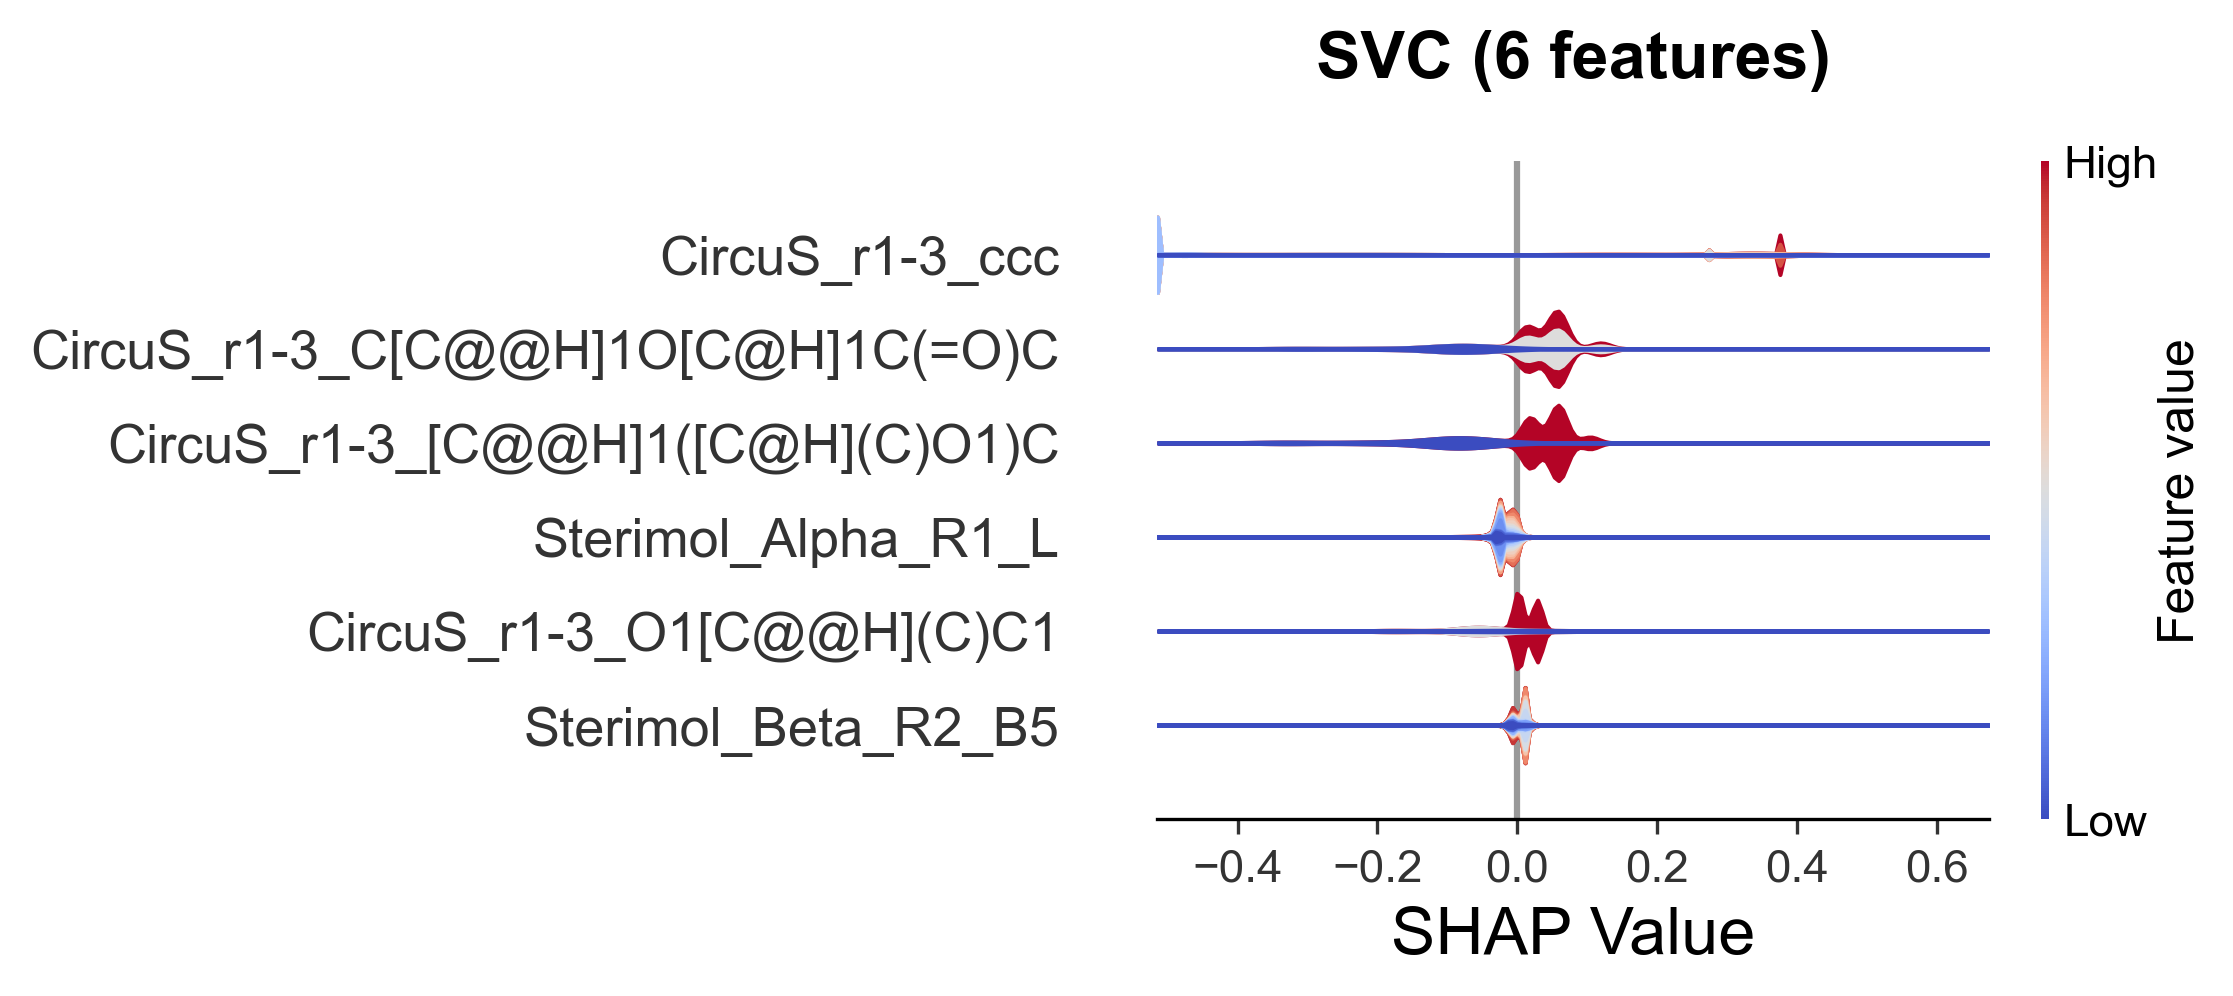

 SVC completed.

PROCESSING: Random Forest
  -> Loading model from: ./Results/Trained_Models/RS42_consensus_n6_fast_aggr_False_RandomForest_model.pkl
  -> Detected model type: RandomForestClassifier
  -> Using TreeExplainer
  -> 3D Array detected (67, 6, 2). Selecting index 1 for classes.
  -> Saving plot to: Figures/SHAP_Comparison/SHAP_violin_Random_Forest_6feats.svg


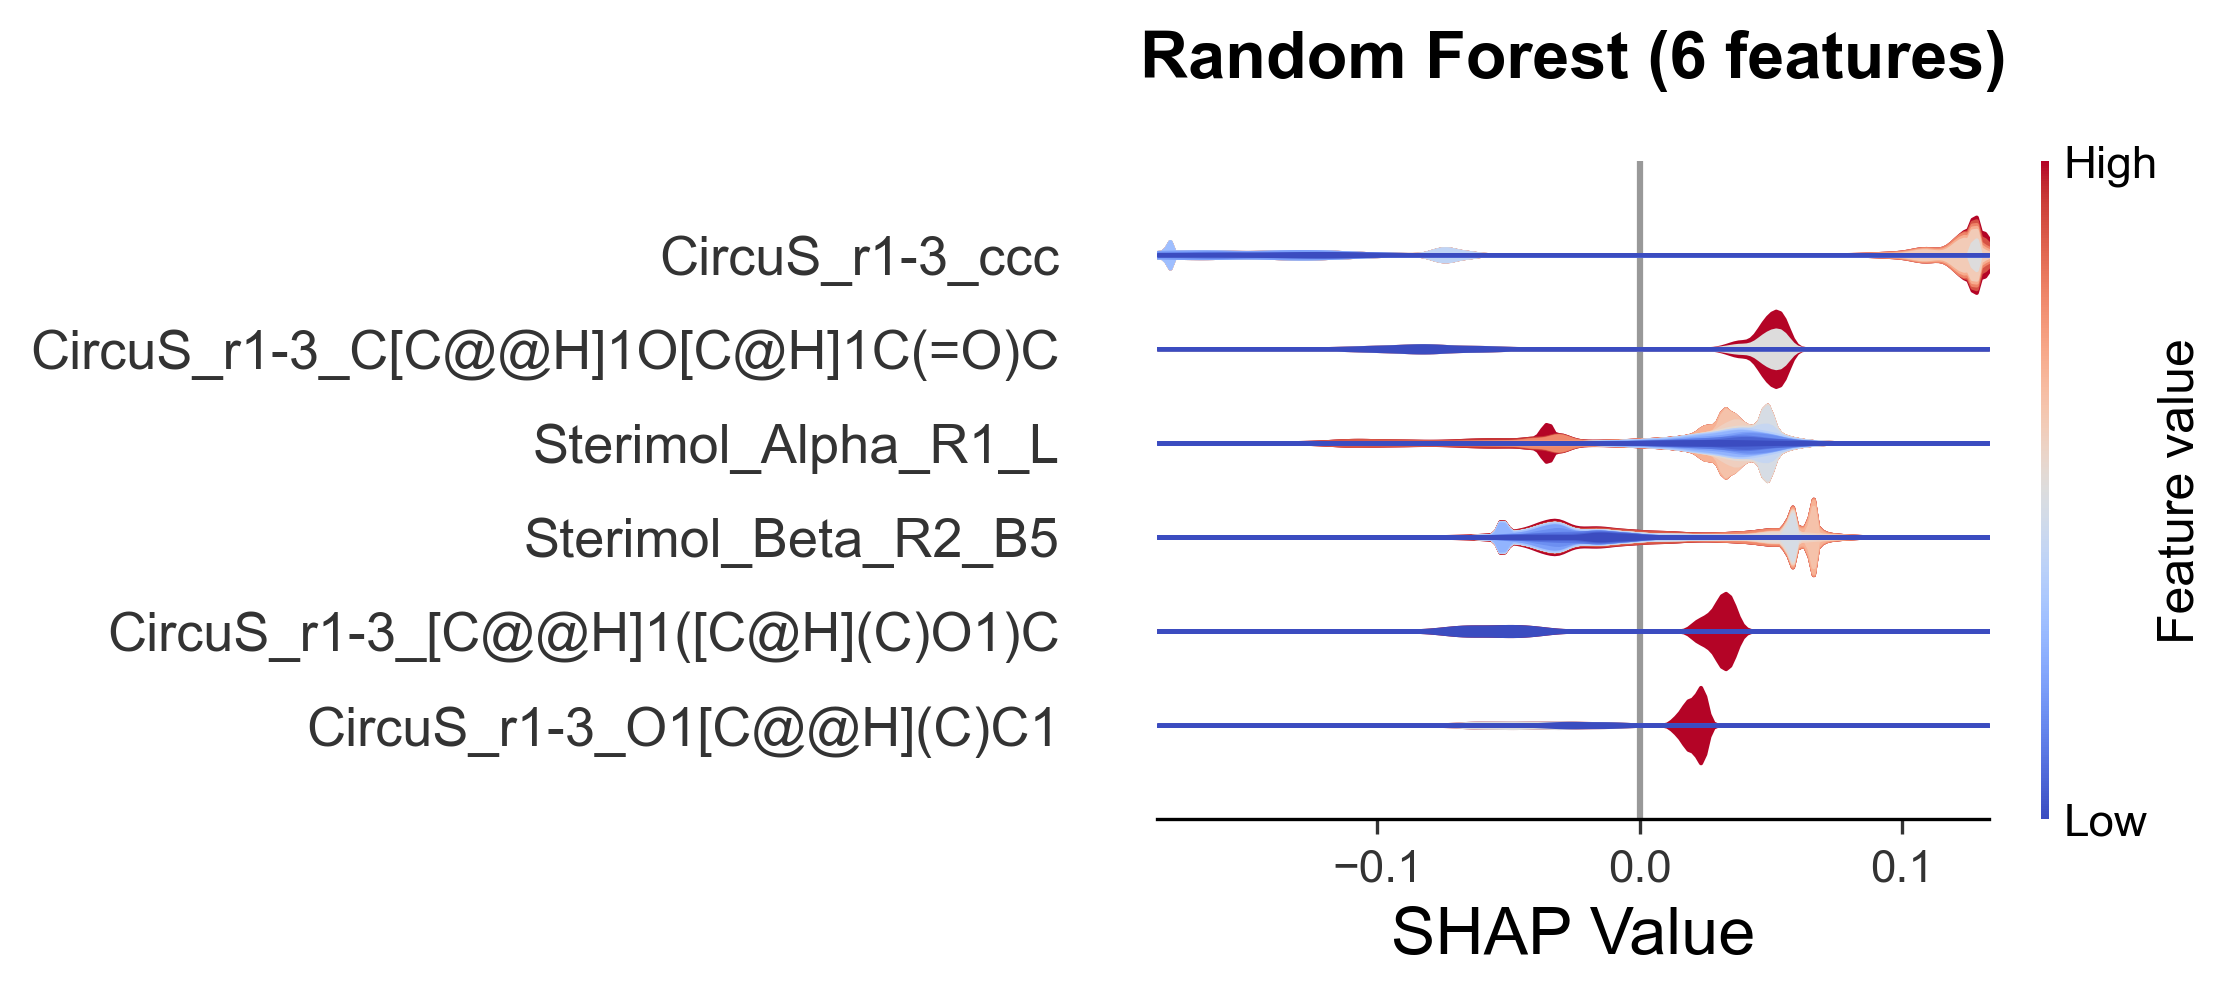

 Random Forest completed.

PROCESSING: XGBoost
  -> Loading model from: ./Results/Trained_Models/RS42_consensus_n6_fast_aggr_False_XGBoost_model.pkl
  -> Detected model type: XGBClassifier
  -> Using TreeExplainer
 Error processing XGBoost: feature_names must be string, and may not contain [, ] or <

PROCESSING: Gradient Boosting
  -> Loading model from: ./Results/Trained_Models/RS42_consensus_n6_fast_aggr_False_GradientBoosting_model.pkl
  -> Detected model type: GradientBoostingClassifier
  -> Using TreeExplainer
  -> Saving plot to: Figures/SHAP_Comparison/SHAP_violin_Gradient_Boosting_6feats.svg


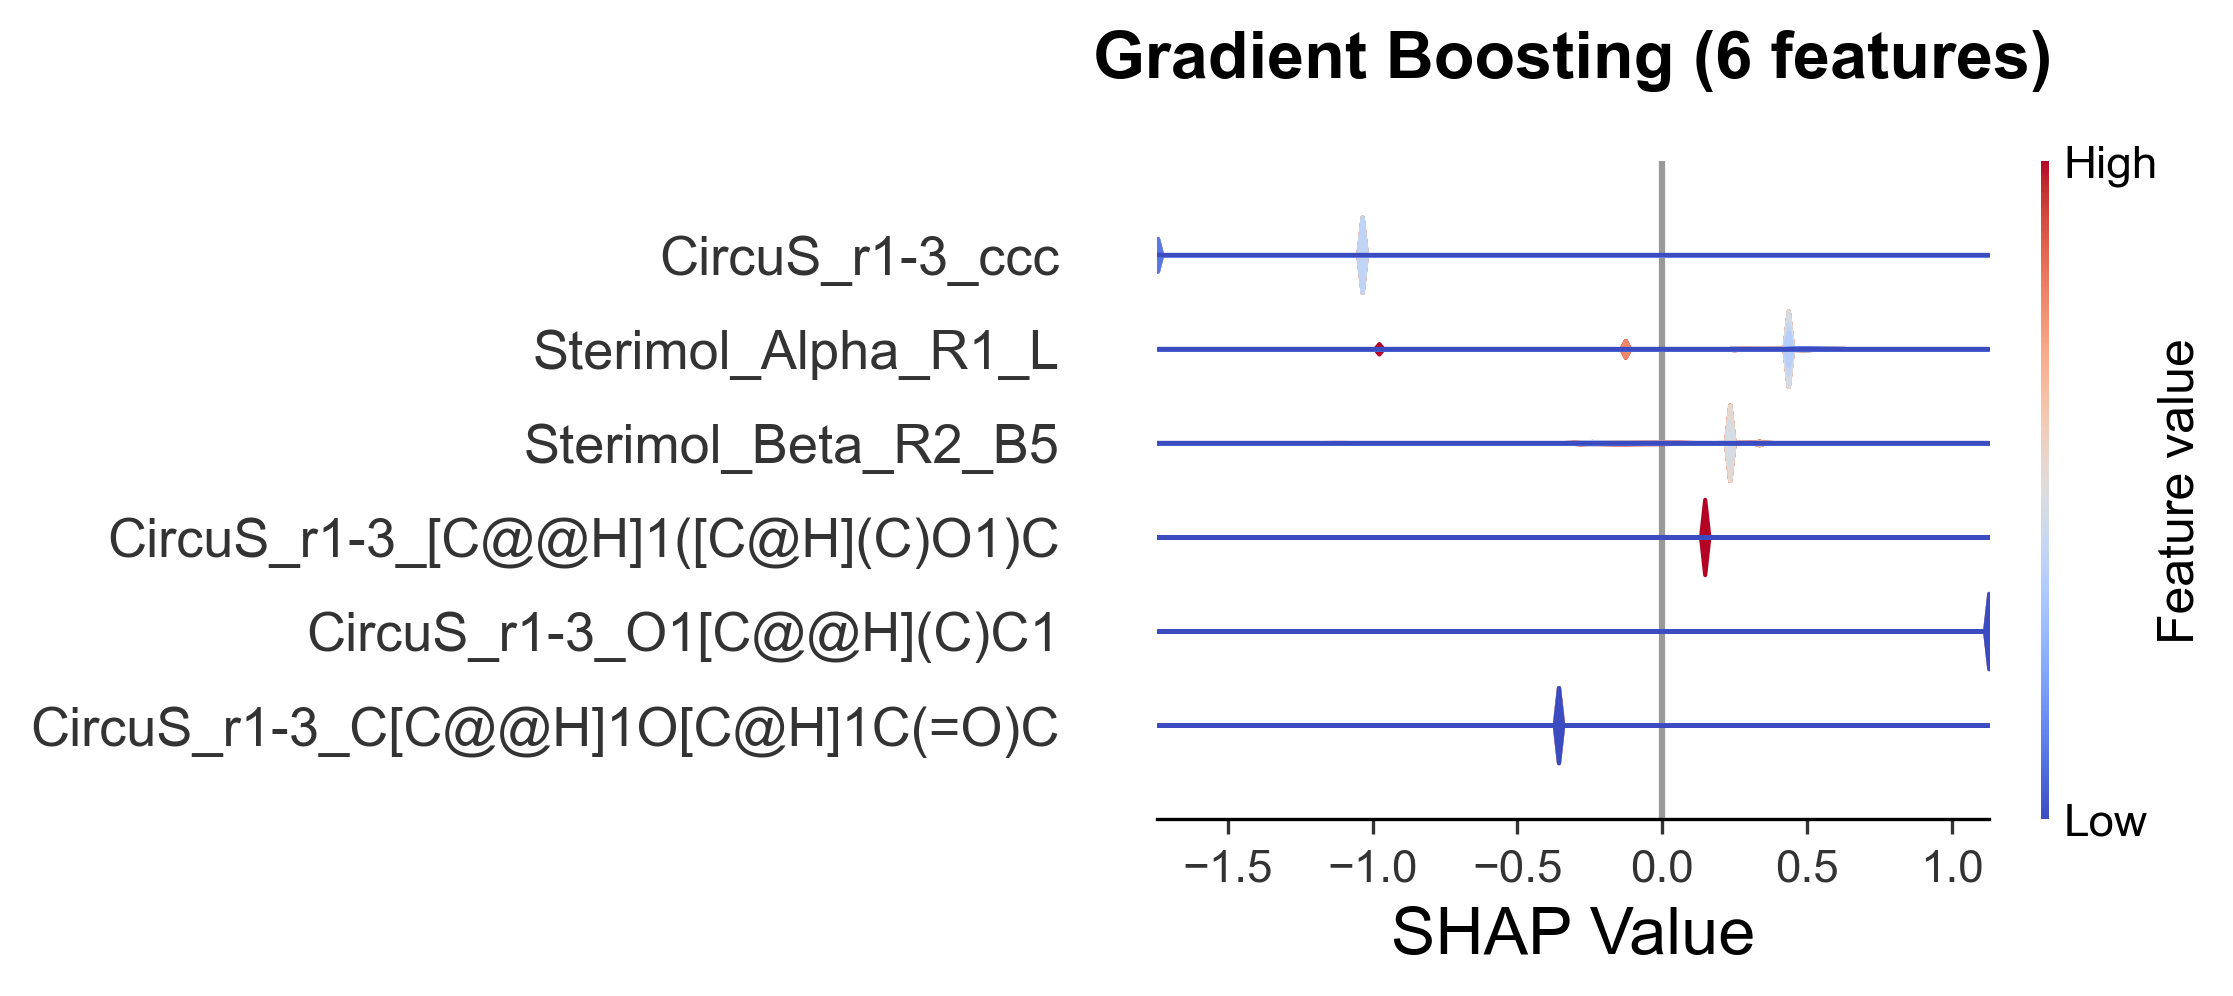

 Gradient Boosting completed.

PROCESSING: KNN
  -> Loading model from: ./Results/Trained_Models/RS42_consensus_n6_fast_aggr_False_KNN_model.pkl
  -> Detected model type: KNeighborsClassifier
  -> Using KernelExplainer


  0%|          | 0/67 [00:00<?, ?it/s]

  -> Saving plot to: Figures/SHAP_Comparison/SHAP_violin_KNN_6feats.svg


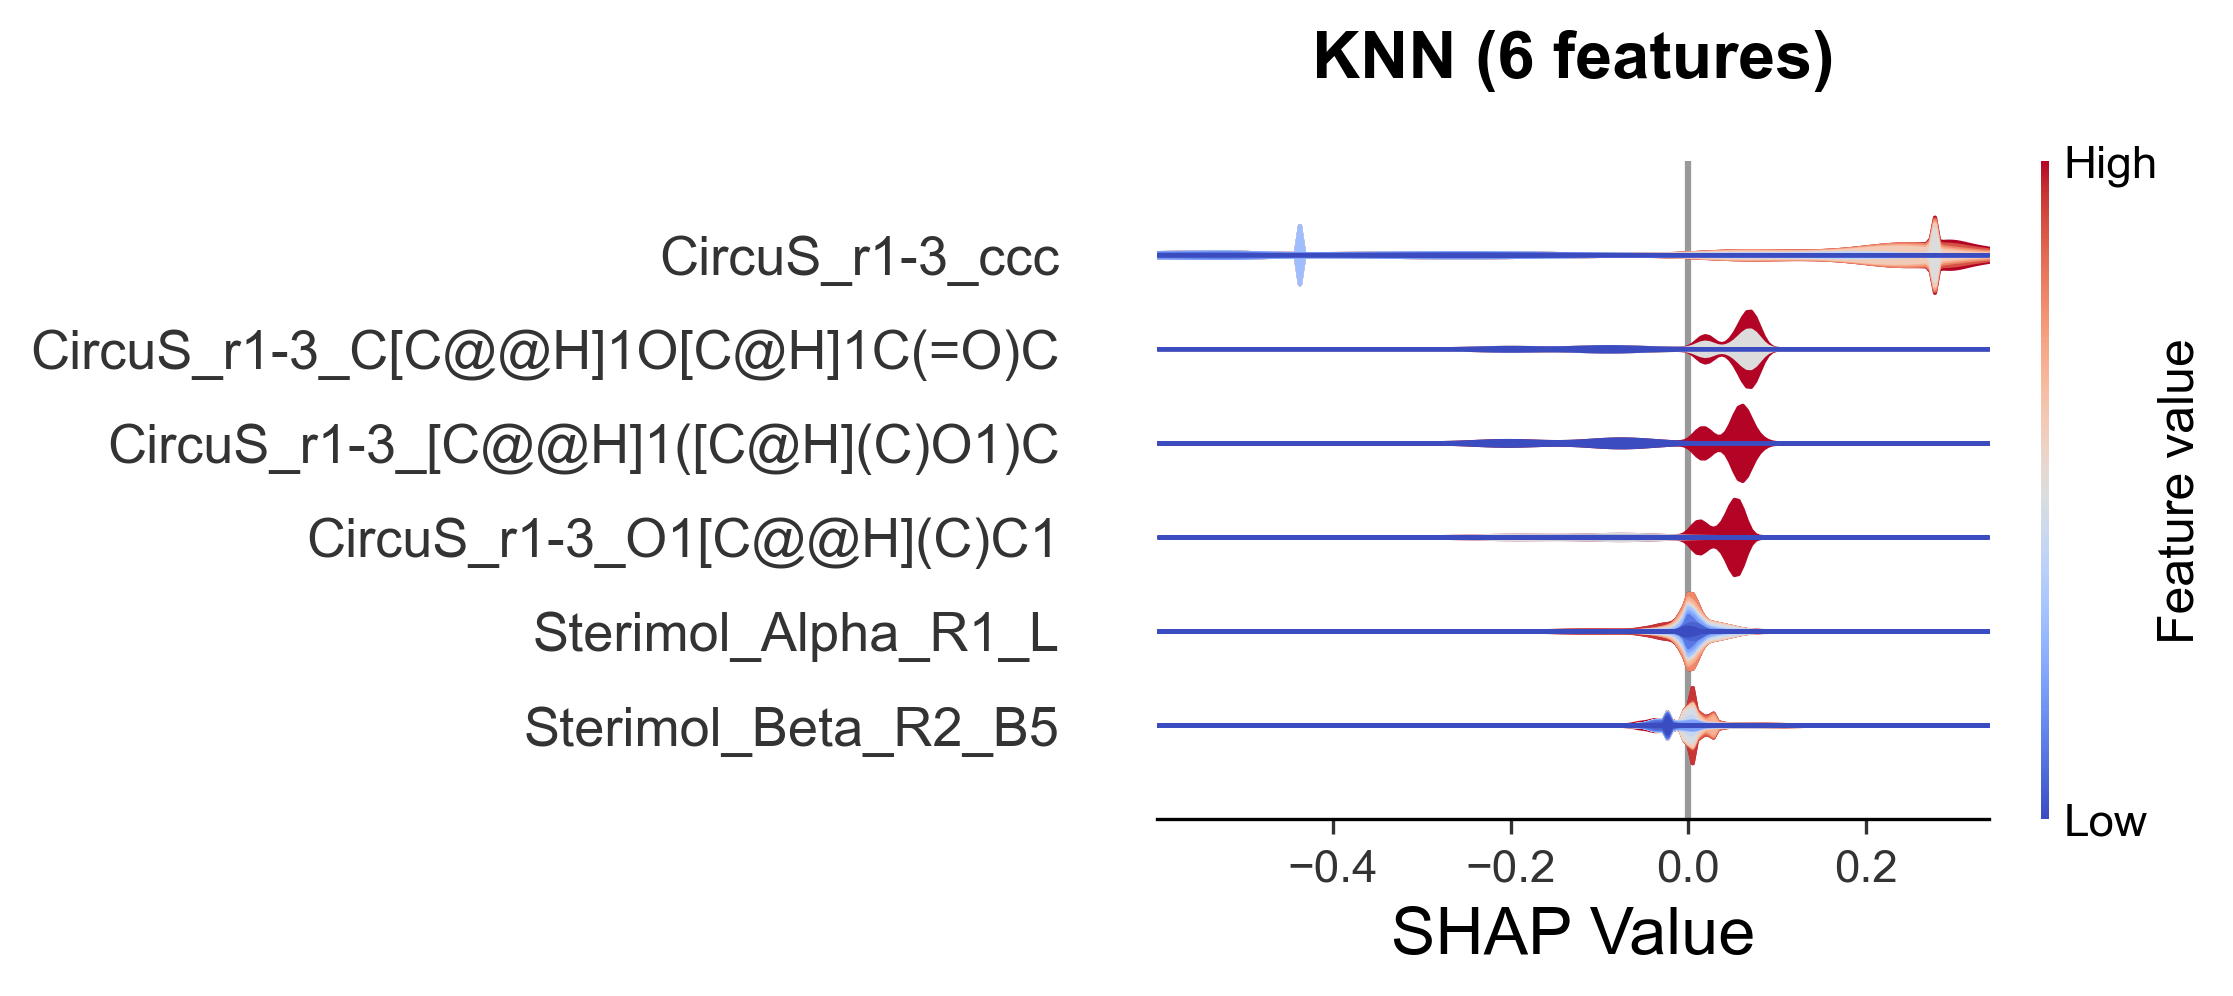

 KNN completed.

PROCESSING: Decision Tree
  -> Loading model from: ./Results/Trained_Models/RS42_consensus_n6_fast_aggr_False_DecisionTree_model.pkl
  -> Detected model type: DecisionTreeClassifier
  -> Using TreeExplainer
  -> 3D Array detected (67, 6, 2). Selecting index 1 for classes.
  -> Saving plot to: Figures/SHAP_Comparison/SHAP_violin_Decision_Tree_6feats.svg


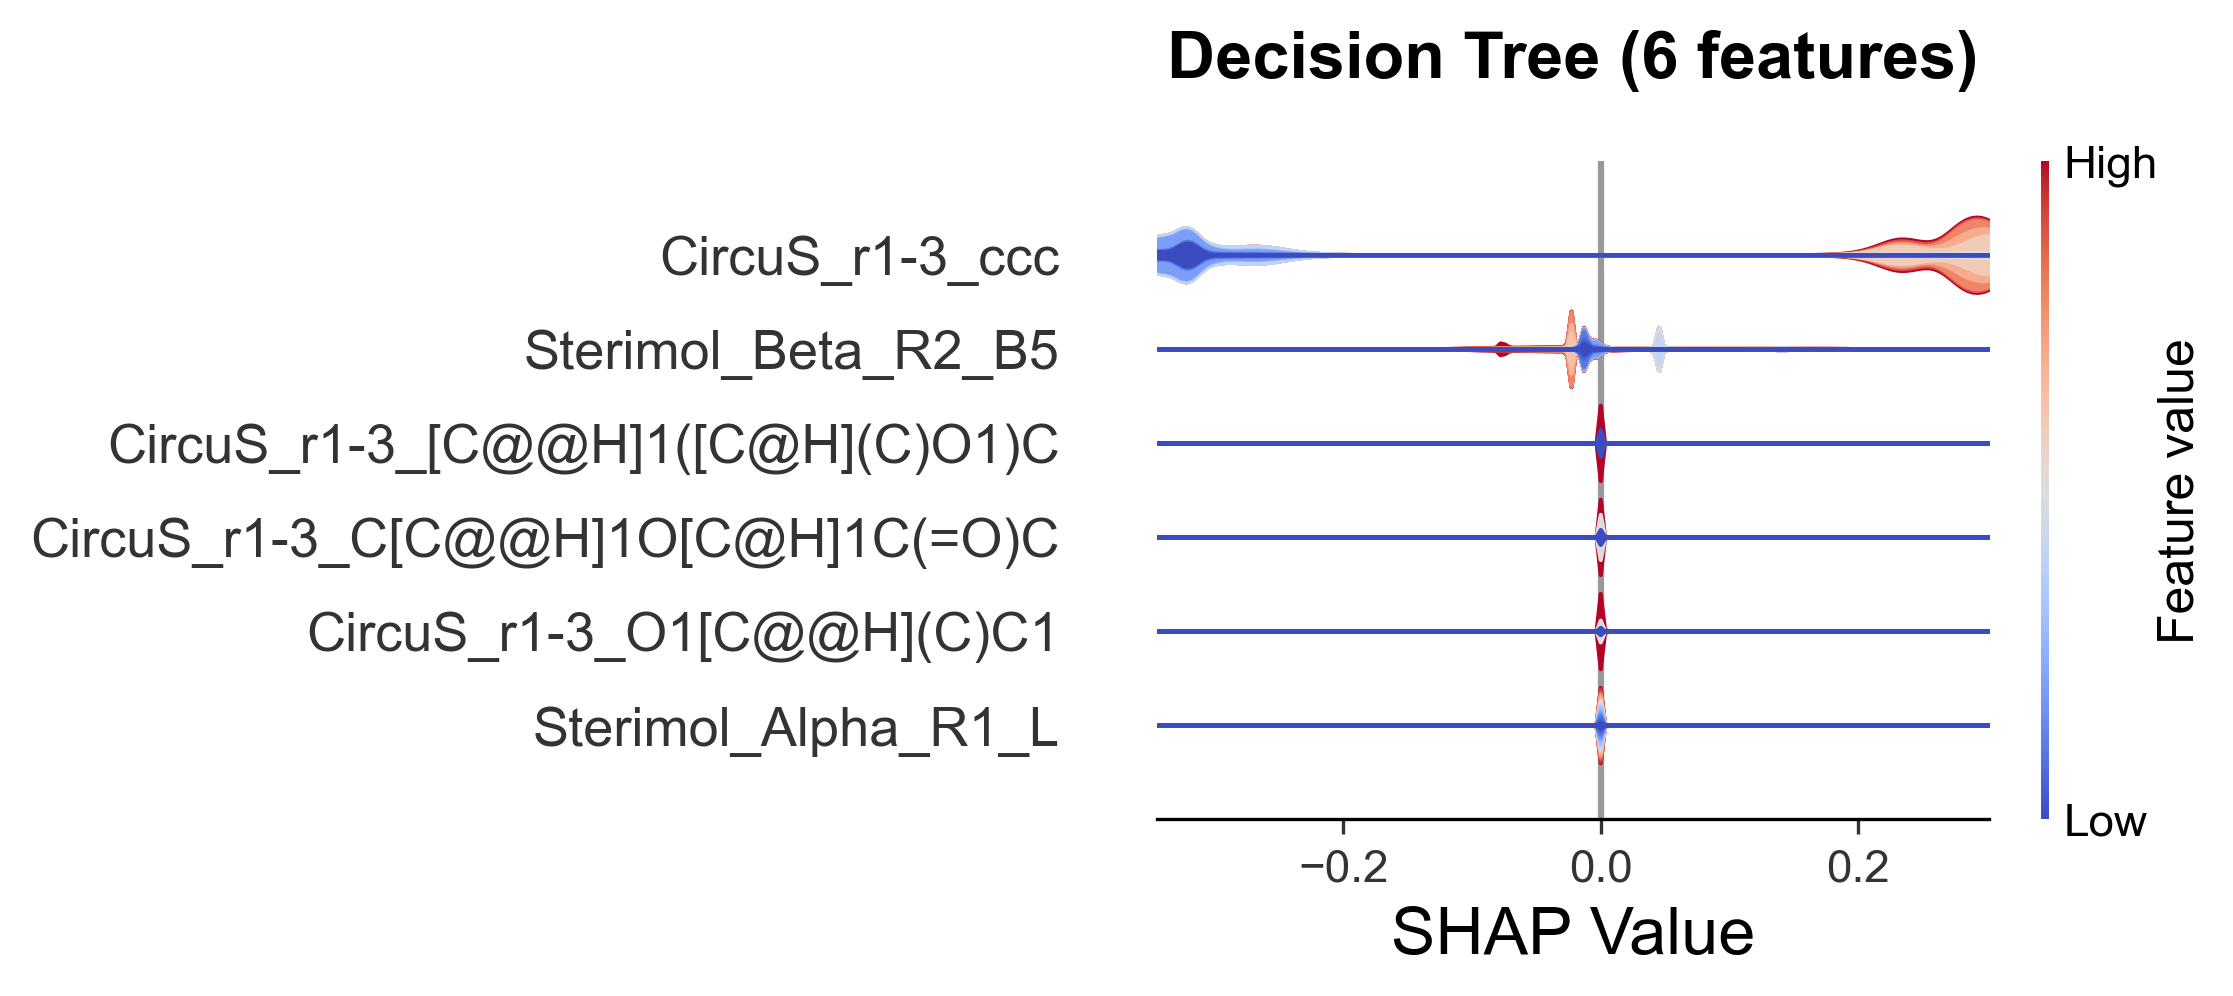

 Decision Tree completed.

PROCESSING: LogReg
  -> Loading model from: ./Results/Trained_Models/RS42_consensus_n6_fast_aggr_False_LogisticRegression_model.pkl
  -> Detected model type: LogisticRegression
  -> Using KernelExplainer


  0%|          | 0/67 [00:00<?, ?it/s]

  -> Saving plot to: Figures/SHAP_Comparison/SHAP_violin_LogReg_6feats.svg


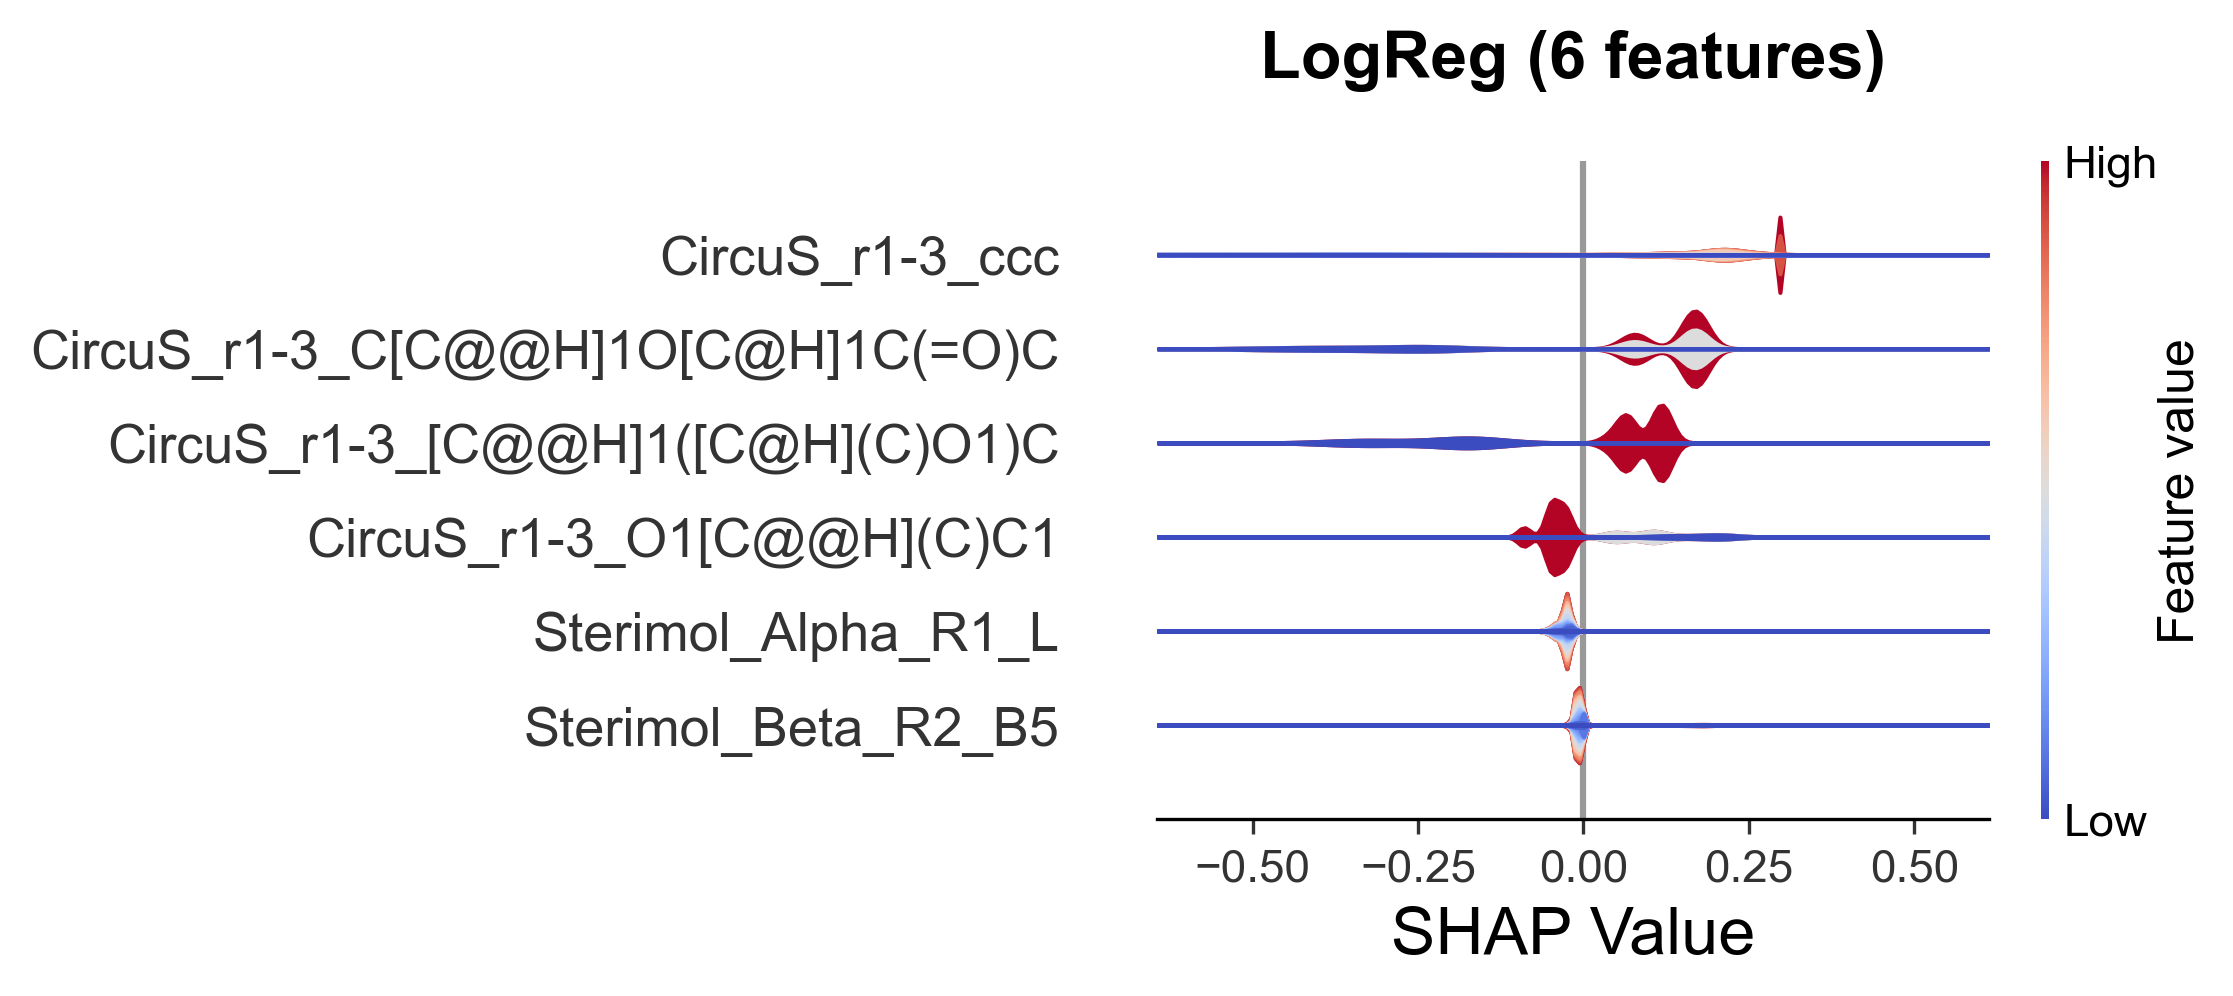

 LogReg completed.

All models processed.


In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================

TRAIN_DATA_PATH = './Results/Selected_Data/RS42_consensus_n6_fast_aggr_False_train_data.parquet'
TEST_DATA_PATH  = './Results/Selected_Data/RS42_consensus_n6_fast_aggr_False_test_data.parquet'
FIGURES_DIR     = 'Figures/SHAP_Comparison'
TARGET_COL      = 'epox_cla'

MODELS_CONFIG = {
    'SVC':           './Results/Trained_Models/RS42_consensus_n6_fast_aggr_False_SVC_model.pkl',
    'Random Forest': './Results/Trained_Models/RS42_consensus_n6_fast_aggr_False_RandomForest_model.pkl', 
    'XGBoost':       './Results/Trained_Models/RS42_consensus_n6_fast_aggr_False_XGBoost_model.pkl',
    'Gradient Boosting': './Results/Trained_Models/RS42_consensus_n6_fast_aggr_False_GradientBoosting_model.pkl',
    'KNN':           './Results/Trained_Models/RS42_consensus_n6_fast_aggr_False_KNN_model.pkl',
    'Decision Tree': './Results/Trained_Models/RS42_consensus_n6_fast_aggr_False_DecisionTree_model.pkl',
    'LogReg': './Results/Trained_Models/RS42_consensus_n6_fast_aggr_False_LogisticRegression_model.pkl'
}
# ============================================================================
# MAIN EXECUTION LOOP
# ============================================================================

if __name__ == "__main__":
    
    print(f"Starting Multi-Model SHAP Analysis...")
    print(f"{'='*60}")
    
    for model_name, model_path in MODELS_CONFIG.items():
        print(f"\nPROCESSING: {model_name}")
        
        # 1. Load Data & Model
        X_data, model_obj = load_data_and_extract_estimator(
            TRAIN_DATA_PATH, TEST_DATA_PATH, model_path, TARGET_COL
        )
        
        if model_obj is None:
            continue
            
        # 2. Calculate SHAP
        try:
            sh_values = get_shap_values(model_obj, X_data)
            
            # 3. Plot
            create_publication_violin_plot(sh_values, X_data, model_name, FIGURES_DIR)
            print(f" {model_name} completed.")
            
        except Exception as e:
            print(f" Error processing {model_name}: {e}")
            
    print(f"\n{'='*60}")
    print("All models processed.")
